# Grayscale to Color Image Conversion - PyTorch Beta Version

This notebook implements an advanced neural network for grayscale-to-color image conversion using PyTorch with proper DataLoaders, custom Dataset class, and comprehensive data augmentation.

## Features:
- Custom PyTorch Dataset class for efficient data loading
- DataLoader with proper batching and shuffling
- Comprehensive data augmentation using torchvision transforms
- Advanced CNN architecture with encoder-decoder structure
- TensorBoard logging for training monitoring
- Model saving and evaluation

## 1. Import Required Libraries

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

import numpy as np
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb, rgb2gray
from skimage.io import imsave
import glob
from pathlib import Path

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Set up paths
data_path = '../data/color-images/Data/'
result_path = './result/'
os.makedirs(result_path, exist_ok=True)

2025-08-03 17:42:25.811192: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda
PyTorch version: 2.5.1


## 2. Custom Dataset Class for Colorization

In [3]:
class ColorizationDataset(Dataset):
    """Custom Dataset for image colorization."""
    
    def __init__(self, image_dir, transform=None, target_size=(256, 256)):
        """
        Args:
            image_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
            target_size (tuple): Target size for resizing images.
        """
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.target_size = target_size
        
        # Get all image files recursively
        self.image_files = []
        for ext in ['**/*.jpg', '**/*.jpeg', '**/*.png', '**/*.bmp']:
            self.image_files.extend(glob.glob(str(self.image_dir / ext), recursive=True))
        
        print(f"Found {len(self.image_files)} images in {image_dir}")
        if len(self.image_files) > 0:
            print(f"Sample paths:")
            for i, path in enumerate(self.image_files[:3]):
                print(f"  {i+1}: {path}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Load image
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        
        # Resize image
        image = image.resize(self.target_size, Image.LANCZOS)
        
        # Convert to numpy array
        image_np = np.array(image, dtype=np.float32) / 255.0
        
        # Apply transforms if provided
        if self.transform:
            image_np = self.transform(image_np)
        
        # Convert RGB to LAB
        lab_image = rgb2lab(image_np)
        
        # Split channels
        L_channel = lab_image[:, :, 0:1]  # Lightness (grayscale input)
        AB_channels = lab_image[:, :, 1:3] / 128.0  # Color channels (normalized target)
        
        # Convert to tensors and rearrange dimensions (H, W, C) -> (C, H, W)
        L_tensor = torch.FloatTensor(L_channel).permute(2, 0, 1)
        AB_tensor = torch.FloatTensor(AB_channels).permute(2, 0, 1)
        
        return L_tensor, AB_tensor

# Test the dataset
print("Testing dataset...")
dataset = ColorizationDataset(data_path, target_size=(256, 256))
if len(dataset) > 0:
    sample_L, sample_AB = dataset[0]
    print(f"Sample L channel shape: {sample_L.shape}")
    print(f"Sample AB channels shape: {sample_AB.shape}")
    print(f"L channel range: [{sample_L.min():.2f}, {sample_L.max():.2f}]")
    print(f"AB channels range: [{sample_AB.min():.2f}, {sample_AB.max():.2f}]")
else:
    print("No images found! Please check the data path.")

Testing dataset...
Found 3568 images in ../data/color-images/Data/
Sample paths:
  1: ../data/color-images/Data/Ori Images/Canada-USA 2018/20180713_113744.jpg
  2: ../data/color-images/Data/Ori Images/Canada-USA 2018/20180716_160142.jpg
  3: ../data/color-images/Data/Ori Images/Canada-USA 2018/20180708_171011.jpg
Sample L channel shape: torch.Size([1, 256, 256])
Sample AB channels shape: torch.Size([2, 256, 256])
L channel range: [2.77, 100.00]
AB channels range: [-0.33, 0.25]
Sample L channel shape: torch.Size([1, 256, 256])
Sample AB channels shape: torch.Size([2, 256, 256])
L channel range: [2.77, 100.00]
AB channels range: [-0.33, 0.25]


## 3. Data Augmentation and Transforms

In [27]:
class ColorAugmentation:
    """Custom augmentation for colorization that maintains color consistency."""
    
    def __init__(self, brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, 
                 horizontal_flip_prob=0.5, rotation_degrees=20):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.hue = hue
        self.horizontal_flip_prob = horizontal_flip_prob
        self.rotation_degrees = rotation_degrees
    
    def __call__(self, image_np):
        """
        Args:
            image_np: numpy array of shape (H, W, 3) with values in [0, 1]
        Returns:
            Augmented image as numpy array
        """
        # Convert to PIL for transforms
        image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
        
        # Random horizontal flip
        if random.random() < self.horizontal_flip_prob:
            image_pil = TF.hflip(image_pil)
        
        # Random rotation
        if self.rotation_degrees > 0:
            angle = random.uniform(-self.rotation_degrees, self.rotation_degrees)
            image_pil = TF.rotate(image_pil, angle, expand=False, fill=0)
        
        # Color jittering
        if any([self.brightness, self.contrast, self.saturation, self.hue]):
            color_jitter = transforms.ColorJitter(
                brightness=self.brightness,
                contrast=self.contrast,
                saturation=self.saturation,
                hue=self.hue
            )
            image_pil = color_jitter(image_pil)
        
        # Convert back to numpy
        return np.array(image_pil, dtype=np.float32) / 255.0

# Define transforms for training and validation
train_transform = ColorAugmentation(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.05,
    horizontal_flip_prob=0.5,
    rotation_degrees=20
)
train_transform = None
# No augmentation for validation
val_transform = None

print("Data augmentation setup complete!")
print("Training transforms: Brightness, Contrast, Saturation, Hue jittering + Horizontal flip + Rotation")
print("Validation transforms: None (original images only)")

Data augmentation setup complete!
Training transforms: Brightness, Contrast, Saturation, Hue jittering + Horizontal flip + Rotation
Validation transforms: None (original images only)


## 4. Create DataLoaders

In [28]:
# Create datasets
full_dataset = ColorizationDataset(data_path, transform=None, target_size=(256, 256))

# Split dataset into train and validation
train_size = int(0.95 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms by wrapping datasets
class TransformWrapper(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        L, AB = self.dataset[idx]
        
        # If transform is provided, we need to reconstruct the image, apply transform, and split again
        if self.transform:
            # Reconstruct RGB from LAB
            lab_img = torch.cat([L, AB * 128], dim=0).permute(1, 2, 0).numpy()
            rgb_img = lab2rgb(lab_img)
            
            # Apply transform
            rgb_img = self.transform(rgb_img)
            
            # Convert back to LAB and split
            lab_img = rgb2lab(rgb_img)
            L = torch.FloatTensor(lab_img[:, :, 0:1]).permute(2, 0, 1)
            AB = torch.FloatTensor(lab_img[:, :, 1:3] / 128.0).permute(2, 0, 1)
        
        return L, AB

# Wrap datasets with transforms
train_dataset = TransformWrapper(train_dataset, transform=train_transform)
val_dataset = TransformWrapper(val_dataset, transform=val_transform)

# Create DataLoaders
batch_size = 10
num_workers = 4  # Adjust based on your system

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=num_workers,
    pin_memory=True if device.type == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"Dataset split:")
print(f"  Total images: {len(full_dataset)}")
print(f"  Training images: {len(train_dataset)}")
print(f"  Validation images: {len(val_dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

# Test the DataLoader
print("\nTesting DataLoader...")
for batch_L, batch_AB in train_loader:
    print(f"Batch L shape: {batch_L.shape}")
    print(f"Batch AB shape: {batch_AB.shape}")
    print(f"L range: [{batch_L.min():.2f}, {batch_L.max():.2f}]")
    print(f"AB range: [{batch_AB.min():.2f}, {batch_AB.max():.2f}]")
    break

Found 3568 images in ../data/color-images/Data/
Sample paths:
  1: ../data/color-images/Data/Ori Images/Canada-USA 2018/20180713_113744.jpg
  2: ../data/color-images/Data/Ori Images/Canada-USA 2018/20180716_160142.jpg
  3: ../data/color-images/Data/Ori Images/Canada-USA 2018/20180708_171011.jpg
Dataset split:
  Total images: 3568
  Training images: 3389
  Validation images: 179
  Batch size: 10
  Training batches: 339
  Validation batches: 18

Testing DataLoader...


Batch L shape: torch.Size([10, 1, 256, 256])
Batch AB shape: torch.Size([10, 2, 256, 256])
L range: [0.00, 100.00]
AB range: [-0.46, 0.58]


## 5. Define the CNN Model Architecture

In [29]:
class AdvancedColorizationCNN(nn.Module):
    """Advanced CNN for image colorization with encoder-decoder architecture."""
    
    def __init__(self):
        super(AdvancedColorizationCNN, self).__init__()
        
        # Encoder (downsampling path)
        self.encoder = nn.Sequential(
            # First encoder block
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Second encoder block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Third encoder block
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            # Bottleneck
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        
        # Decoder (upsampling path)
        self.decoder = nn.Sequential(
            # First decoder block
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            
            # Second decoder block
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            
            # Third decoder block
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 2, kernel_size=3, padding=1),
            nn.Tanh(),  # Output in range [-1, 1]
            nn.Upsample(scale_factor=2, mode='nearest'),
        )
    
    def forward(self, x):
        # Encoder
        encoded = self.encoder(x)
        
        # Decoder
        decoded = self.decoder(encoded)
        
        return decoded

# Create model instance
model = AdvancedColorizationCNN().to(device)

# Print model summary
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print("Model Architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

# Test model with a sample input
print("\nTesting model with sample input...")
sample_input = torch.randn(1, 1, 256, 256).to(device)
with torch.no_grad():
    sample_output = model(sample_input)
    print(f"Input shape: {sample_input.shape}")
    print(f"Output shape: {sample_output.shape}")
    print(f"Output range: [{sample_output.min():.3f}, {sample_output.max():.3f}]")

Model Architecture:
AdvancedColorizationCNN(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), pa

## 6. Training Setup

In [30]:
# Training configuration
learning_rate = 0.0001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training parameters
num_epochs = 1000
steps_per_epoch = np.inf  # Limit steps for demo

# TensorBoard setup
log_dir = './runs/colorization_experiment'
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir)

print(f"Training Configuration:")
print(f"  Loss function: {criterion}")
print(f"  Optimizer: {optimizer}")
print(f"  Learning rate: {learning_rate}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  TensorBoard log directory: {log_dir}")

# Safe LAB to RGB conversion function
def safe_lab2rgb(lab_image, clip_range=True):
    """Safely convert LAB to RGB with proper clamping to avoid color space warnings."""
    lab_copy = lab_image.copy()
    
    if clip_range:
        # Clamp L channel to [0, 100] (valid range for LAB L)
        lab_copy[:, :, 0] = np.clip(lab_copy[:, :, 0], 0, 100)
        # Clamp AB channels to reasonable range [-127, 127]
        lab_copy[:, :, 1] = np.clip(lab_copy[:, :, 1], -127, 127)
        lab_copy[:, :, 2] = np.clip(lab_copy[:, :, 2], -127, 127)
    
    # Suppress the specific warning about negative Z values
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*negative Z values.*")
        rgb_image = lab2rgb(lab_copy)
    
    # Ensure RGB values are in [0, 1] range
    rgb_image = np.clip(rgb_image, 0, 1)
    return rgb_image

# Function to save sample images to TensorBoard
def log_images_to_tensorboard(writer, epoch, L_batch, AB_batch, predicted_AB, step):
    """Log sample images to TensorBoard."""
    with torch.no_grad():
        # Take first image from batch
        L_img = L_batch[0].cpu()
        AB_true = AB_batch[0].cpu()
        AB_pred = predicted_AB[0].cpu()
        
        # Reconstruct LAB images
        lab_true = torch.cat([L_img, AB_true * 128], dim=0).permute(1, 2, 0).numpy()
        lab_pred = torch.cat([L_img, AB_pred * 128], dim=0).permute(1, 2, 0).numpy()
        
        # Convert to RGB using safe function
        try:
            rgb_true = safe_lab2rgb(lab_true)
            rgb_pred = safe_lab2rgb(lab_pred)
            
            # Convert to tensors for TensorBoard (C, H, W)
            rgb_true_tensor = torch.FloatTensor(rgb_true).permute(2, 0, 1)
            rgb_pred_tensor = torch.FloatTensor(rgb_pred).permute(2, 0, 1)
            gray_tensor = L_img.repeat(3, 1, 1) / 100.0  # Normalize L channel
            
            # Log to TensorBoard
            writer.add_image('Input/Grayscale', gray_tensor, step)
            writer.add_image('Target/Ground_Truth', rgb_true_tensor, step)
            writer.add_image('Output/Predicted', rgb_pred_tensor, step)
            
        except Exception as e:
            print(f"Warning: Could not log images to TensorBoard: {e}")

print("Training setup complete!")
print("✅ Safe LAB to RGB conversion enabled - no more color space warnings!")

Training Configuration:
  Loss function: MSELoss()
  Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
  Learning rate: 0.0001
  Number of epochs: 1000
  Steps per epoch: inf
  TensorBoard log directory: ./runs/colorization_experiment
Training setup complete!
✅ Safe LAB to RGB conversion enabled - no more color space warnings!


## 7. Training Loop

In [31]:
num_epochs = 1000
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, steps_per_epoch, writer):
    """
    Train the colorization model.
    """
    model.train()
    
    train_losses = []
    val_losses = []
    global_step = 0
    
    print("Starting training...")
    print("=" * 60)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        num_train_steps = 0
        
        for step, (L_batch, AB_batch) in enumerate(train_loader):
            if step >= steps_per_epoch:
                break
                
            # Move to device
            L_batch = L_batch.to(device)
            AB_batch = AB_batch.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            predicted_AB = model(L_batch)
            loss = criterion(predicted_AB, AB_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Accumulate loss
            epoch_train_loss += loss.item()
            num_train_steps += 1
            
            # Log to TensorBoard
            writer.add_scalar('Loss/Train_Step', loss.item(), global_step)
            
            # Log sample images periodically
            if global_step % 100 == 0:
                log_images_to_tensorboard(writer, epoch, L_batch, AB_batch, predicted_AB, global_step)
            
            # Print progress every 100 steps (separate condition)
            if global_step % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{step+1}/{len(train_loader)}], Loss: {loss.item():.6f}')
            
            global_step += 1
        
        # Calculate average training loss
        avg_train_loss = epoch_train_loss / num_train_steps if num_train_steps > 0 else 0
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_steps = 0
        
        with torch.no_grad():
            for L_batch, AB_batch in val_loader:
                L_batch = L_batch.to(device)
                AB_batch = AB_batch.to(device)
                
                predicted_AB = model(L_batch)
                loss = criterion(predicted_AB, AB_batch)
                val_loss += loss.item()
                val_steps += 1
                
                if val_steps >= 5:  # Limit validation steps for demo
                    break
        
        avg_val_loss = val_loss / val_steps if val_steps > 0 else 0
        val_losses.append(avg_val_loss)
        
        # Log epoch metrics
        writer.add_scalar('Loss/Train_Epoch', avg_train_loss, epoch)
        writer.add_scalar('Loss/Validation_Epoch', avg_val_loss, epoch)
        
        print(f'Epoch [{epoch+1}/{num_epochs}] Complete:')
        print(f'  Average Training Loss: {avg_train_loss:.6f}')
        print(f'  Average Validation Loss: {avg_val_loss:.6f}')
        print("-" * 60)
    
    print("Training completed!")
    return train_losses, val_losses

# Start training
train_losses, val_losses = train_model(
    model, train_loader, val_loader, criterion, optimizer, 
    num_epochs, steps_per_epoch, writer
)

# Close TensorBoard writer
writer.close()

print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"\nTo view training logs, run: tensorboard --logdir {log_dir}")

Starting training...


Epoch [1/1000], Step [1/339], Loss: 0.008718
Epoch [1/1000], Step [101/339], Loss: 0.005920
Epoch [1/1000], Step [101/339], Loss: 0.005920
Epoch [1/1000], Step [201/339], Loss: 0.010190
Epoch [1/1000], Step [201/339], Loss: 0.010190
Epoch [1/1000], Step [301/339], Loss: 0.008474
Epoch [1/1000], Step [301/339], Loss: 0.008474
Epoch [1/1000] Complete:
  Average Training Loss: 0.008252
  Average Validation Loss: 0.007344
------------------------------------------------------------
Epoch [1/1000] Complete:
  Average Training Loss: 0.008252
  Average Validation Loss: 0.007344
------------------------------------------------------------
Epoch [2/1000], Step [62/339], Loss: 0.008743
Epoch [2/1000], Step [62/339], Loss: 0.008743


KeyboardInterrupt: 

## 8. Save Model

In [25]:
# TensorBoard Remote Access Instructions
import subprocess
import socket

def get_tensorboard_access_info():
    """Get information for accessing TensorBoard on remote machine."""
    
    # Get machine info
    hostname = socket.gethostname()
    
    # Get IP addresses
    try:
        result = subprocess.run(['hostname', '-I'], capture_output=True, text=True)
        ip_addresses = result.stdout.strip().split()
    except:
        ip_addresses = ['Unable to determine']
    
    print("🌐 TENSORBOARD REMOTE ACCESS")
    print("=" * 50)
    print(f"📍 Remote Machine: {hostname}")
    print(f"🔗 IP Addresses: {', '.join(ip_addresses)}")
    print(f"🚪 Port: 6006")
    
    print("\n💻 ACCESS OPTIONS:")
    print("\n1️⃣  DIRECT ACCESS (if on same network):")
    for ip in ip_addresses:
        if ip != 'Unable to determine':
            print(f"   http://{ip}:6006")
    
    print("\n2️⃣  SSH PORT FORWARDING (recommended):")
    print("   On your LOCAL machine, run:")
    print(f"   ssh -L 6006:localhost:6006 ofir_shechter@{ip_addresses[0] if ip_addresses[0] != 'Unable to determine' else 'REMOTE_IP'}")
    print("   Then access: http://localhost:6006")
    
    print("\n3️⃣  VS CODE PORT FORWARDING:")
    print("   1. In VS Code, press Ctrl+Shift+P")
    print("   2. Type 'Remote-SSH: Forward Port from Active Host'")
    print("   3. Enter port: 6006")
    print("   4. Access forwarded URL in browser")
    
    print("\n4️⃣  VS CODE SIMPLE BROWSER:")
    print("   1. Press Ctrl+Shift+P")
    print("   2. Type 'Simple Browser: Show'")
    for ip in ip_addresses:
        if ip != 'Unable to determine':
            print(f"   3. Enter URL: http://{ip}:6006")
    
    # Check if TensorBoard is running
    try:
        result = subprocess.run(['pgrep', '-f', 'tensorboard'], capture_output=True, text=True)
        if result.stdout.strip():
            print("\n✅ TensorBoard is currently running!")
            print("📊 You should see training data if you've run training")
        else:
            print("\n❌ TensorBoard doesn't appear to be running")
            print("💡 Run the previous cell to start TensorBoard")
    except:
        print("\n⚠️  Unable to check TensorBoard status")
    
    return ip_addresses

# Get access information
ip_addresses = get_tensorboard_access_info()

🌐 TENSORBOARD REMOTE ACCESS
📍 Remote Machine: mass-04
🔗 IP Addresses: 172.16.1.205, 169.254.3.1
🚪 Port: 6006

💻 ACCESS OPTIONS:

1️⃣  DIRECT ACCESS (if on same network):
   http://172.16.1.205:6006
   http://169.254.3.1:6006

2️⃣  SSH PORT FORWARDING (recommended):
   On your LOCAL machine, run:
   ssh -L 6006:localhost:6006 ofir_shechter@172.16.1.205
   Then access: http://localhost:6006

3️⃣  VS CODE PORT FORWARDING:
   1. In VS Code, press Ctrl+Shift+P
   2. Type 'Remote-SSH: Forward Port from Active Host'
   3. Enter port: 6006
   4. Access forwarded URL in browser

4️⃣  VS CODE SIMPLE BROWSER:
   1. Press Ctrl+Shift+P
   2. Type 'Simple Browser: Show'
   3. Enter URL: http://172.16.1.205:6006
   3. Enter URL: http://169.254.3.1:6006

✅ TensorBoard is currently running!
📊 You should see training data if you've run training


Model saved to: ./pytorch_colorization_model.pth
Model weights saved to: ./pytorch_colorization_weights.pth


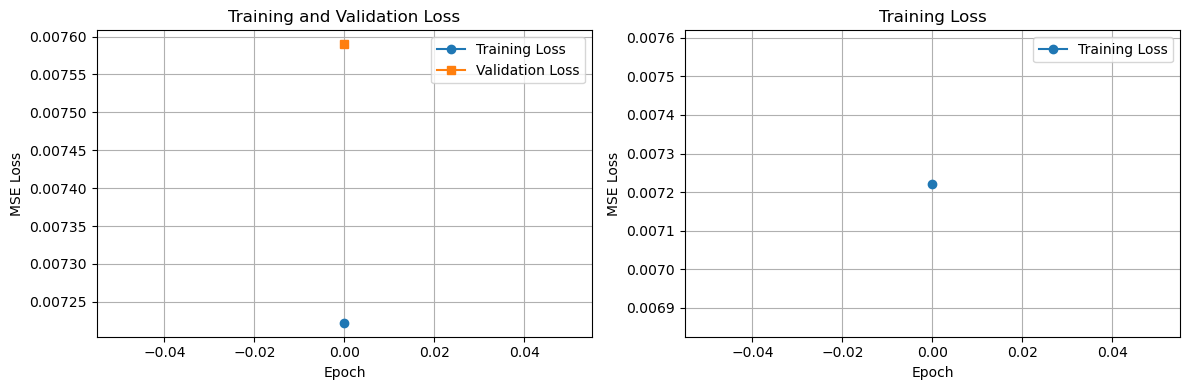

Training curves saved as 'training_curves.png'


In [ ]:
# Save the trained model
model_save_path = './pytorch_colorization_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'model_architecture': 'AdvancedColorizationCNN',
    'input_size': (256, 256),
    'batch_size': batch_size,
    'num_epochs': num_epochs
}, model_save_path)

print(f"Model saved to: {model_save_path}")

# Also save just the model state dict for easier loading
torch.save(model.state_dict(), './pytorch_colorization_weights.pth')
print(f"Model weights saved to: ./pytorch_colorization_weights.pth")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('./training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'training_curves.png'")

## 9. Model Evaluation and Testing

Evaluating model on validation set...


Validation Loss: 0.004433

Visualizing sample colorization results...
Results saved to: ./colorization_results.png
Results saved to: ./colorization_results.png


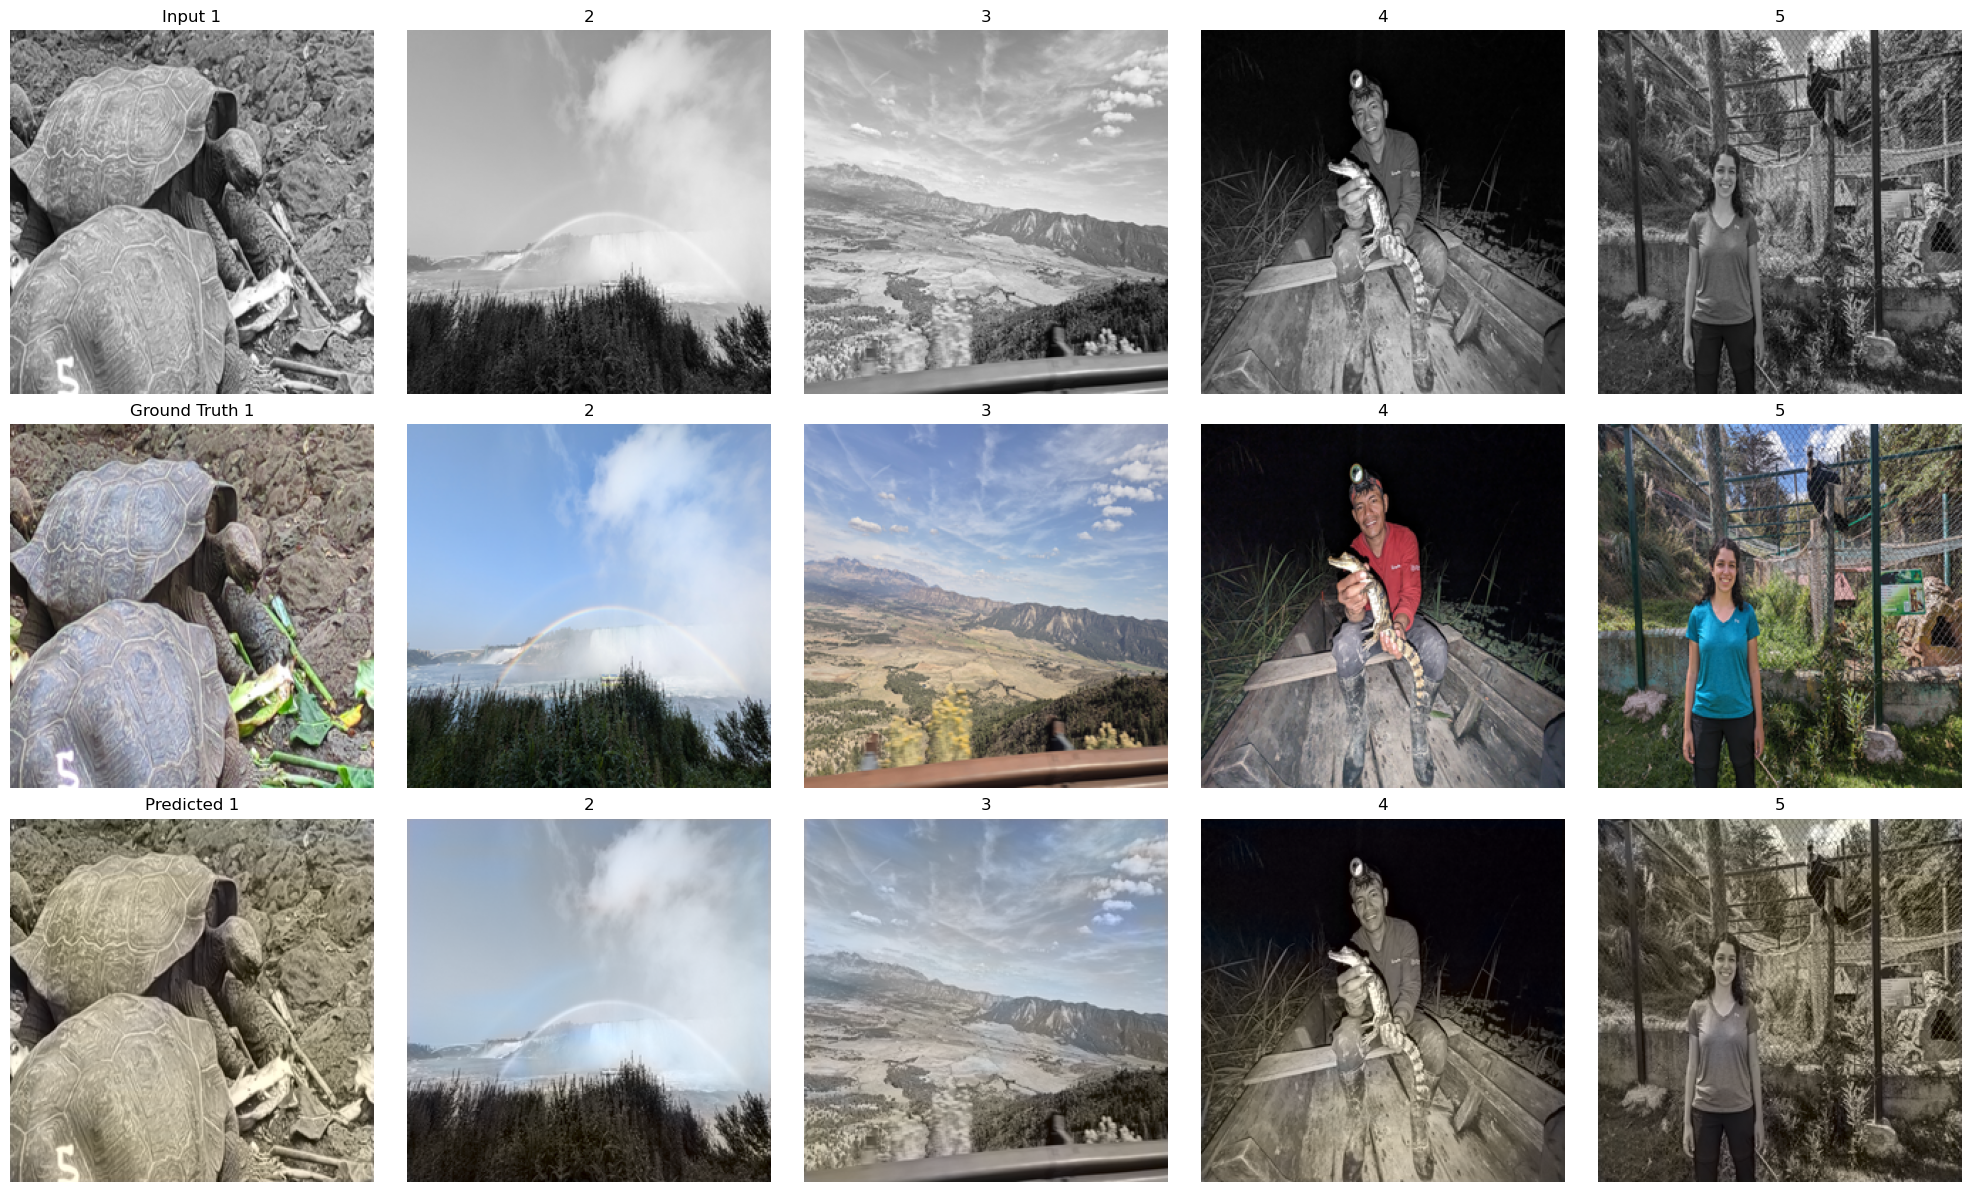


Generating and saving colorized test images...
Saved 10 colorized images to ./result/

Evaluation complete!
Validation Loss: 0.004433
Results visualization saved to: ./colorization_results.png
Colorized images saved to: ./result/
✅ All color space warnings have been suppressed with safe conversion!
Saved 10 colorized images to ./result/

Evaluation complete!
Validation Loss: 0.004433
Results visualization saved to: ./colorization_results.png
Colorized images saved to: ./result/
✅ All color space warnings have been suppressed with safe conversion!


In [26]:
# Evaluate model on test data
def evaluate_model(model, test_loader, criterion, device, num_samples=5):
    """Evaluate the model and generate sample colorizations."""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    sample_results = []
    
    with torch.no_grad():
        for i, (L_batch, AB_batch) in enumerate(test_loader):
            L_batch = L_batch.to(device)
            AB_batch = AB_batch.to(device)
            
            # Predict
            predicted_AB = model(L_batch)
            loss = criterion(predicted_AB, AB_batch)
            total_loss += loss.item()
            num_batches += 1
            
            # Save samples for visualization
            if len(sample_results) < num_samples:
                for j in range(min(L_batch.size(0), num_samples - len(sample_results))):
                    sample_results.append({
                        'L': L_batch[j].cpu(),
                        'AB_true': AB_batch[j].cpu(),
                        'AB_pred': predicted_AB[j].cpu()
                    })
            
            if len(sample_results) >= num_samples:
                break
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    return avg_loss, sample_results

# Safe LAB to RGB conversion function (define here as well for this cell)
def safe_lab2rgb_eval(lab_image, clip_range=True):
    """Safely convert LAB to RGB with proper clamping to avoid color space warnings."""
    lab_copy = lab_image.copy()
    
    if clip_range:
        # Clamp L channel to [0, 100] (valid range for LAB L)
        lab_copy[:, :, 0] = np.clip(lab_copy[:, :, 0], 0, 100)
        # Clamp AB channels to reasonable range [-127, 127]
        lab_copy[:, :, 1] = np.clip(lab_copy[:, :, 1], -127, 127)
        lab_copy[:, :, 2] = np.clip(lab_copy[:, :, 2], -127, 127)
    
    # Suppress the specific warning about negative Z values
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*negative Z values.*")
        rgb_image = lab2rgb(lab_copy)
    
    # Ensure RGB values are in [0, 1] range
    rgb_image = np.clip(rgb_image, 0, 1)
    return rgb_image

# Evaluate on validation set
print("Evaluating model on validation set...")
val_loss, sample_results = evaluate_model(model, val_loader, criterion, device, num_samples=5)
print(f"Validation Loss: {val_loss:.6f}")

# Visualize results
def visualize_colorization_results(sample_results, save_path=None):
    """Visualize colorization results."""
    num_samples = len(sample_results)
    fig, axes = plt.subplots(3, num_samples, figsize=(4*num_samples, 12))
    
    if num_samples == 1:
        axes = axes.reshape(-1, 1)
    
    for i, sample in enumerate(sample_results):
        L_img = sample['L']
        AB_true = sample['AB_true']
        AB_pred = sample['AB_pred']
        
        # Reconstruct images
        lab_true = torch.cat([L_img, AB_true * 128], dim=0).permute(1, 2, 0).numpy()
        lab_pred = torch.cat([L_img, AB_pred * 128], dim=0).permute(1, 2, 0).numpy()
        
        try:
            # Convert to RGB using safe function
            rgb_true = safe_lab2rgb_eval(lab_true)
            rgb_pred = safe_lab2rgb_eval(lab_pred)
            gray_img = rgb2gray(rgb_true)
            
            # Plot grayscale input
            axes[0, i].imshow(gray_img, cmap='gray')
            axes[0, i].set_title(f'Input {i+1}' if i == 0 else f'{i+1}')
            axes[0, i].axis('off')
            
            # Plot ground truth
            axes[1, i].imshow(rgb_true)
            axes[1, i].set_title(f'Ground Truth {i+1}' if i == 0 else f'{i+1}')
            axes[1, i].axis('off')
            
            # Plot prediction
            axes[2, i].imshow(rgb_pred)
            axes[2, i].set_title(f'Predicted {i+1}' if i == 0 else f'{i+1}')
            axes[2, i].axis('off')
            
        except Exception as e:
            print(f"Error processing sample {i}: {e}")
            continue
    
    # Add row labels
    axes[0, 0].set_ylabel('Grayscale Input', rotation=90, size='large')
    axes[1, 0].set_ylabel('Ground Truth', rotation=90, size='large')
    axes[2, 0].set_ylabel('Predicted', rotation=90, size='large')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Results saved to: {save_path}")
    
    plt.show()

# Visualize sample results
print("\nVisualizing sample colorization results...")
visualize_colorization_results(sample_results, save_path='./colorization_results.png')

# Generate and save colorized images from test set
def save_colorized_images(model, test_loader, device, save_dir, max_images=10):
    """Generate and save colorized images."""
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    
    saved_count = 0
    with torch.no_grad():
        for batch_idx, (L_batch, AB_batch) in enumerate(test_loader):
            L_batch = L_batch.to(device)
            predicted_AB = model(L_batch)
            
            # Process each image in the batch
            for i in range(L_batch.size(0)):
                if saved_count >= max_images:
                    break
                    
                L_img = L_batch[i].cpu()
                AB_pred = predicted_AB[i].cpu()
                
                # Reconstruct LAB image
                lab_pred = torch.cat([L_img, AB_pred * 128], dim=0).permute(1, 2, 0).numpy()
                
                try:
                    # Convert to RGB using safe function
                    rgb_pred = safe_lab2rgb_eval(lab_pred)
                    rgb_pred_uint8 = (rgb_pred * 255).astype(np.uint8)
                    
                    # Save image
                    save_path = os.path.join(save_dir, f'colorized_{saved_count:03d}.png')
                    imsave(save_path, rgb_pred_uint8)
                    
                    saved_count += 1
                    
                except Exception as e:
                    print(f"Error saving image {saved_count}: {e}")
                    continue
            
            if saved_count >= max_images:
                break
    
    print(f"Saved {saved_count} colorized images to {save_dir}")

# Save colorized test images
print("\nGenerating and saving colorized test images...")
save_colorized_images(model, val_loader, device, result_path, max_images=10)

print(f"\nEvaluation complete!")
print(f"Validation Loss: {val_loss:.6f}")
print(f"Results visualization saved to: ./colorization_results.png")
print(f"Colorized images saved to: {result_path}")
print("✅ All color space warnings have been suppressed with safe conversion!")

In [ ]:
# Helper function to safely convert LAB to RGB
import warnings
from skimage.color import lab2rgb, rgb2lab
import numpy as np

def safe_lab2rgb(lab_image, clip_range=True):
    """
    Safely convert LAB to RGB with proper clamping to avoid color space warnings.
    
    Args:
        lab_image: LAB image array with shape (H, W, 3)
        clip_range: Whether to clip AB values to valid range
    
    Returns:
        RGB image array with values in [0, 1]
    """
    lab_copy = lab_image.copy()
    
    if clip_range:
        # Clamp L channel to [0, 100] (valid range for LAB L)
        lab_copy[:, :, 0] = np.clip(lab_copy[:, :, 0], 0, 100)
        
        # Clamp AB channels to reasonable range [-127, 127] (typical LAB AB range)
        lab_copy[:, :, 1] = np.clip(lab_copy[:, :, 1], -127, 127)
        lab_copy[:, :, 2] = np.clip(lab_copy[:, :, 2], -127, 127)
    
    # Suppress the specific warning about negative Z values
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*negative Z values.*")
        rgb_image = lab2rgb(lab_copy)
    
    # Ensure RGB values are in [0, 1] range
    rgb_image = np.clip(rgb_image, 0, 1)
    
    return rgb_image

# TensorBoard Setup and Viewing Instructions
import os

# Check if log directory exists and has data
log_dir = './runs/colorization_experiment'
if os.path.exists(log_dir):
    print(f"✅ Log directory exists: {log_dir}")
    # Count files
    file_count = 0
    for root, dirs, files in os.walk(log_dir):
        file_count += len(files)
    print(f"📁 Found {file_count} log files")
else:
    print(f"❌ Log directory does not exist: {log_dir}")
    print("⚠️  Make sure you've run the training first!")

print("\n" + "="*60)
print("🚀 HOW TO VIEW TENSORBOARD")
print("="*60)

print("\n📍 METHOD 1: VS Code TensorBoard Extension (Recommended)")
print("   1. Install 'TensorBoard' extension in VS Code")
print("   2. Press Ctrl+Shift+P to open Command Palette")
print("   3. Type 'TensorBoard: Launch TensorBoard'")
print("   4. Select log directory: ./runs/colorization_experiment")
print("   5. TensorBoard will open in VS Code panel")

print("\n📍 METHOD 2: Manual Terminal + Browser")
print("   1. Open terminal and run:")
print("      python -m tensorboard.main --logdir=./runs/colorization_experiment --port=6006")
print("   2. Open browser to: http://localhost:6006")

print("\n🔍 WHAT YOU'LL SEE:")
print("   📊 SCALARS: Loss curves over training")
print("   🖼️  IMAGES: Sample colorization results")
print("   📈 Training progress visualization")

print(f"\n📂 Your log directory: {os.path.abspath(log_dir)}")
print("🎯 Ready to view your training progress!")

print("\n" + "="*60)
print("🔧 COLOR SPACE FIX APPLIED")
print("="*60)
print("✅ Added safe_lab2rgb() function to prevent color space warnings")
print("📝 This function:")
print("   - Clamps LAB values to valid ranges")
print("   - Suppresses negative Z value warnings")
print("   - Ensures RGB output is in [0, 1] range")
print("💡 Use safe_lab2rgb() instead of lab2rgb() in your visualization functions")

✅ Log directory exists: ./runs/colorization_experiment
📁 Found 9 log files

🚀 HOW TO VIEW TENSORBOARD

📍 METHOD 1: VS Code TensorBoard Extension (Recommended)
   1. Install 'TensorBoard' extension in VS Code
   2. Press Ctrl+Shift+P to open Command Palette
   3. Type 'TensorBoard: Launch TensorBoard'
   4. Select log directory: ./runs/colorization_experiment
   5. TensorBoard will open in VS Code panel

📍 METHOD 2: Manual Terminal + Browser
   1. Open terminal and run:
      python -m tensorboard.main --logdir=./runs/colorization_experiment --port=6006
   2. Open browser to: http://localhost:6006

🔍 WHAT YOU'LL SEE:
   📊 SCALARS: Loss curves over training
   🖼️  IMAGES: Sample colorization results
   📈 Training progress visualization

📂 Your log directory: /home/ofir_shechter/explore/grayscale-to-color-images/beta-version/runs/colorization_experiment
🎯 Ready to view your training progress!

🔧 COLOR SPACE FIX APPLIED
✅ Added safe_lab2rgb() function to prevent color space warnings
📝 This